## Summary & Key Findings

### Dataset Overview
- **Total Records**: {{records}}
- **Total Features**: {{features}}

### Target Variable
- **Binary Target**: Readmitted within 30 days (1) vs. Others (0)
- **Class Imbalance**: Only ~11% readmitted within 30 days → **SMOTE required**

### Missing Values
- **Columns with >90% missing**: Weight (drop)
- **Columns with 50-90% missing**: payer_code, medical_specialty (handle carefully)

### Key Predictors
- num_medications, time_in_hospital, num_diagnoses correlate with readmission
- Clinical and demographic factors show promise for prediction

### Demographic Disparities
- Readmission rates vary significantly by race and gender
- Foundation for Phase 5 fairness analysis

### Next Steps
1. **Phase 2** (02_preprocessing.ipynb): Data cleaning, feature engineering, SMOTE
2. **Phase 3** (03_modeling.ipynb): Train baseline and advanced models with class weights
3. **Phase 4** (04_explainability.ipynb): SHAP analysis for model interpretability
4. **Phase 5** (05_fairness.ipynb): Detailed fairness assessment


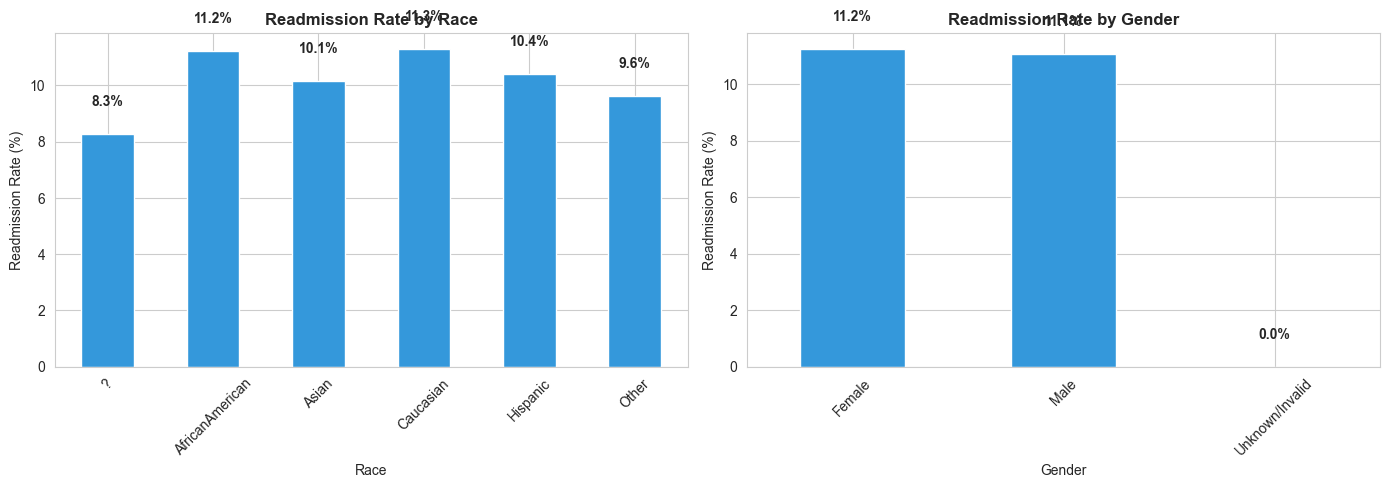


⚠️ Fairness Consideration:
Significant disparities in readmission rates across demographic groups warrant further investigation.
Phase 5 (05_fairness.ipynb) will conduct detailed fairness analysis.


In [22]:
# Visualize demographic disparities
demographic_analysis = {}

if 'race' in df.columns:
    demographic_analysis['race'] = df.groupby('race')['readmitted_binary'].apply(lambda x: (x.sum() / len(x) * 100))

if 'gender' in df.columns:
    demographic_analysis['gender'] = df.groupby('gender')['readmitted_binary'].apply(lambda x: (x.sum() / len(x) * 100))

# Create visualization
n_plots = len(demographic_analysis)
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(14, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    for idx, (demo_col, data) in enumerate(demographic_analysis.items()):
        data.plot(kind='bar', ax=axes[idx], color='#3498db')
        axes[idx].set_title(f'Readmission Rate by {demo_col.capitalize()}', fontweight='bold')
        axes[idx].set_ylabel('Readmission Rate (%)')
        axes[idx].set_xlabel(demo_col.capitalize())
        axes[idx].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for i, v in enumerate(data):
            axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("\n⚠️ Fairness Consideration:")
print("Significant disparities in readmission rates across demographic groups warrant further investigation.")
print("Phase 5 (05_fairness.ipynb) will conduct detailed fairness analysis.")


In [23]:
# Analyze readmission rates by demographic groups
if 'race' in df.columns:
    print("Readmission Rate by Race:")
    race_readmit = df.groupby('race')['readmitted_binary'].agg(['count', 'sum', 'mean'])
    race_readmit.columns = ['Total_Patients', 'Readmitted_Count', 'Readmission_Rate']
    race_readmit['Readmission_Rate_Percent'] = race_readmit['Readmission_Rate'] * 100
    print(race_readmit)

if 'gender' in df.columns:
    print("\n" + "="*80)
    print("Readmission Rate by Gender:")
    gender_readmit = df.groupby('gender')['readmitted_binary'].agg(['count', 'sum', 'mean'])
    gender_readmit.columns = ['Total_Patients', 'Readmitted_Count', 'Readmission_Rate']
    gender_readmit['Readmission_Rate_Percent'] = gender_readmit['Readmission_Rate'] * 100
    print(gender_readmit)

# Check for age-related columns
age_cols = [col for col in df.columns if 'age' in col.lower()]
if age_cols:
    print("\n" + "="*80)
    print(f"Age-related columns found: {age_cols}")


Readmission Rate by Race:
                 Total_Patients  Readmitted_Count  Readmission_Rate  \
race                                                                  
?                          2273               188          0.082710   
AfricanAmerican           19210              2155          0.112181   
Asian                       641                65          0.101404   
Caucasian                 76099              8592          0.112906   
Hispanic                   2037               212          0.104075   
Other                      1506               145          0.096282   

                 Readmission_Rate_Percent  
race                                       
?                                8.271007  
AfricanAmerican                 11.218116  
Asian                           10.140406  
Caucasian                       11.290556  
Hispanic                        10.407462  
Other                            9.628154  

Readmission Rate by Gender:
                 Total_P

In [24]:
# Check for demographic columns
demographic_cols = [col for col in df.columns if col.lower() in ['race', 'gender', 'age', 'ethnicity']]
print(f"Available demographic columns: {demographic_cols}")
print(f"\nAll columns: {df.columns.tolist()[:20]}...")  # Show first 20 columns

# Check for similar column names
print("\nColumns containing 'race', 'gender', or 'age':")
for col in df.columns:
    if any(x in col.lower() for x in ['race', 'gender', 'age', 'sex']):
        print(f"  - {col}")


Available demographic columns: ['race', 'gender', 'age']

All columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2']...

Columns containing 'race', 'gender', or 'age':
  - race
  - gender
  - age


## 6. Perform Demographic Analysis

Analyze readmission rates stratified by demographic factors:
- **Race**: Identify disparities in readmission rates across racial groups
- **Gender**: Compare readmission patterns between males and females
- **Age Groups**: Understand readmission risk across age ranges

This analysis seeds the **fairness investigation** in Phase 5 (05_fairness.ipynb).


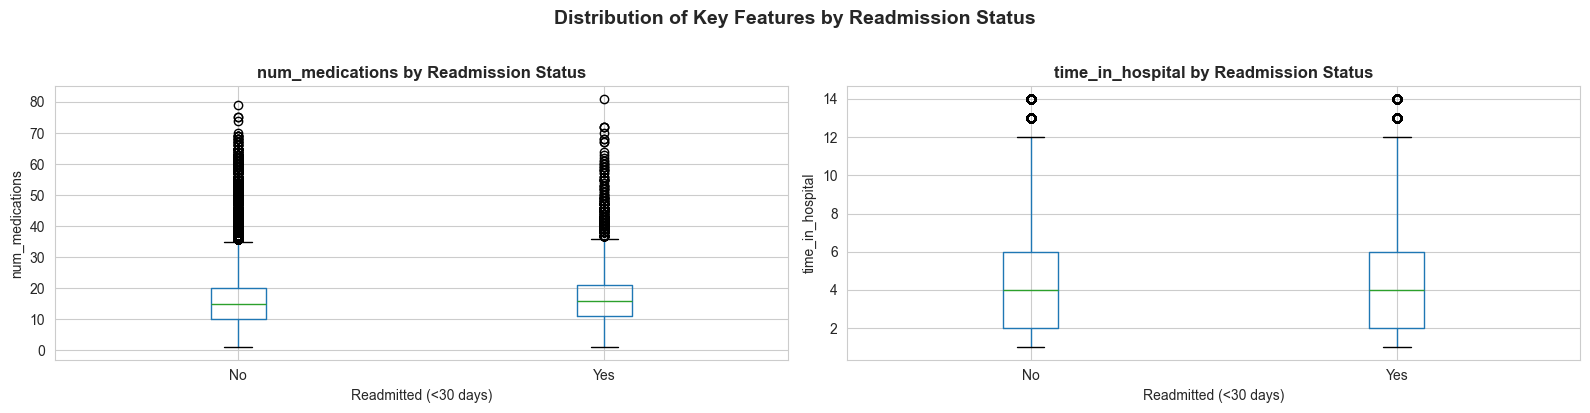


Feature Statistics by Readmission Status:

num_medications:
                     count   mean   std  min   25%   50%   75%   max
readmitted_binary                                                   
0                  90409.0  15.91  8.12  1.0  10.0  15.0  20.0  79.0
1                  11357.0  16.90  8.10  1.0  11.0  16.0  21.0  81.0

time_in_hospital:
                     count  mean   std  min  25%  50%  75%   max
readmitted_binary                                               
0                  90409.0  4.35  2.98  1.0  2.0  4.0  6.0  14.0
1                  11357.0  4.77  3.03  1.0  2.0  4.0  6.0  14.0


In [25]:
# Scatter plots for key features vs. readmission
key_features = ['num_medications', 'time_in_hospital', 'num_diagnoses']
existing_features = [col for col in key_features if col in df.columns]

fig, axes = plt.subplots(1, len(existing_features), figsize=(16, 4))

for idx, feature in enumerate(existing_features):
    # Box plot to show distribution by readmission status
    df.boxplot(column=feature, by='readmitted_binary', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Readmission Status', fontweight='bold')
    axes[idx].set_xlabel('Readmitted (<30 days)')
    axes[idx].set_ylabel(feature)
    axes[idx].set_xticklabels(['No', 'Yes'])
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No', 'Yes'])

plt.suptitle('Distribution of Key Features by Readmission Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calculate statistics for key features by readmission status
print("\nFeature Statistics by Readmission Status:")
for feature in existing_features:
    print(f"\n{feature}:")
    print(df.groupby('readmitted_binary')[feature].describe().round(2))


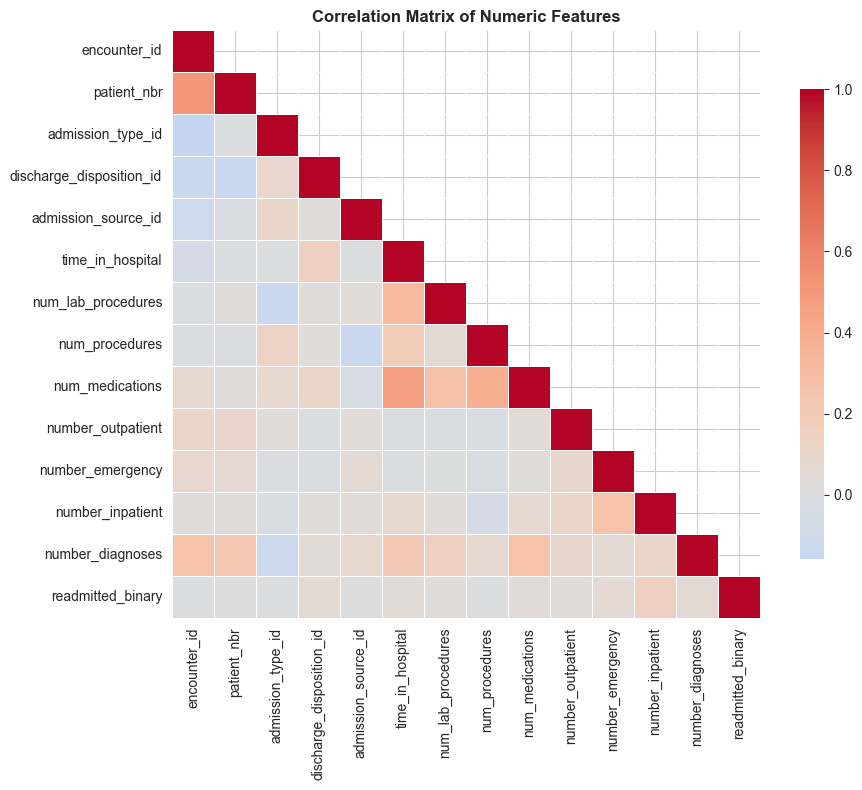

In [26]:
# Create correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, mask=mask, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
# Identify numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns available: {len(numeric_cols)}")
print(f"Key columns for analysis: {[col for col in numeric_cols if col in ['num_medications', 'time_in_hospital', 'num_diagnoses']]}")

# Calculate correlation with readmission target
corr_with_target = df[numeric_cols].corrwith(df['readmitted_binary']).abs().sort_values(ascending=False)
print("\nTop correlations with readmission (<30 days) (by absolute value):")
print(corr_with_target.head(10))
print("\nLowest correlations with readmission (<30 days):")
print(corr_with_target.tail(5))

Numeric columns available: 14
Key columns for analysis: ['time_in_hospital', 'num_medications']

Top correlations with readmission (<30 days) (by absolute value):
readmitted_binary           1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
num_procedures              0.012227
dtype: float64

Lowest correlations with readmission (<30 days):
num_procedures         0.012227
admission_type_id      0.011651
encounter_id           0.008519
patient_nbr            0.007893
admission_source_id    0.005820
dtype: float64


## 5. Analyze Feature Correlations

We examine key numeric features that are likely predictive of readmission:
- `num_medications`: Number of distinct medications
- `time_in_hospital`: Length of hospital stay
- `num_diagnoses`: Number of diagnoses
- `A1Cresult`: Hemoglobin A1c test result (diabetes control indicator)


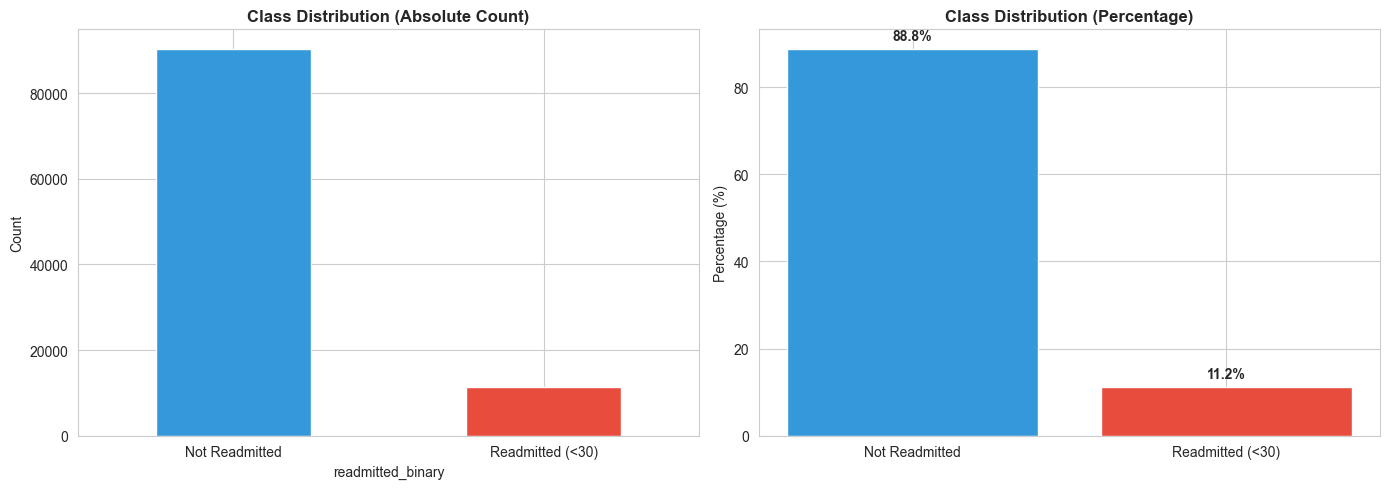


⚠️ Class Imbalance Warning:
The minority class (readmitted <30 days) is severely underrepresented.
This requires:
  • SMOTE or class weighting during model training
  • Use of ROC-AUC score instead of accuracy for evaluation
  • Careful consideration of precision vs. recall trade-offs


In [28]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['readmitted_binary'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Class Distribution (Absolute Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted (<30)'], rotation=0)

# Percentage plot
percentages = df['readmitted_binary'].value_counts(normalize=True) * 100
axes[1].bar(['Not Readmitted', 'Readmitted (<30)'], percentages, color=['#3498db', '#e74c3c'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(percentages):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ Class Imbalance Warning:")
print("The minority class (readmitted <30 days) is severely underrepresented.")
print("This requires:")
print("  • SMOTE or class weighting during model training")
print("  • Use of ROC-AUC score instead of accuracy for evaluation")
print("  • Careful consideration of precision vs. recall trade-offs")


In [29]:
# Quantify class imbalance
imbalance_stats = df['readmitted_binary'].value_counts(normalize=True) * 100
imbalance_ratio = df['readmitted_binary'].value_counts()

print("Class Imbalance Analysis:")
print(f"Readmitted (<30 days): {imbalance_stats[1]:.2f}% ({imbalance_ratio[1]} samples)")
print(f"Not readmitted (>30 or NO): {imbalance_stats[0]:.2f}% ({imbalance_ratio[0]} samples)")
print(f"\nImbalance Ratio: 1:{int(imbalance_ratio[0]/imbalance_ratio[1])}")
print(f"Minority class percentage: {imbalance_stats[1]:.2f}%")


Class Imbalance Analysis:
Readmitted (<30 days): 11.16% (11357 samples)
Not readmitted (>30 or NO): 88.84% (90409 samples)

Imbalance Ratio: 1:7
Minority class percentage: 11.16%


## 4. Examine Class Imbalance

Only ~11% of patients are readmitted within 30 days. This severe class imbalance requires special handling:

**Mitigation Strategies:**
- **SMOTE**: Oversampling minority class (in preprocessing notebook)
- **Class Weights**: Penalize misclassification of minority class (in modeling notebook)
- **Evaluation Metrics**: Use ROC-AUC and F1 instead of accuracy


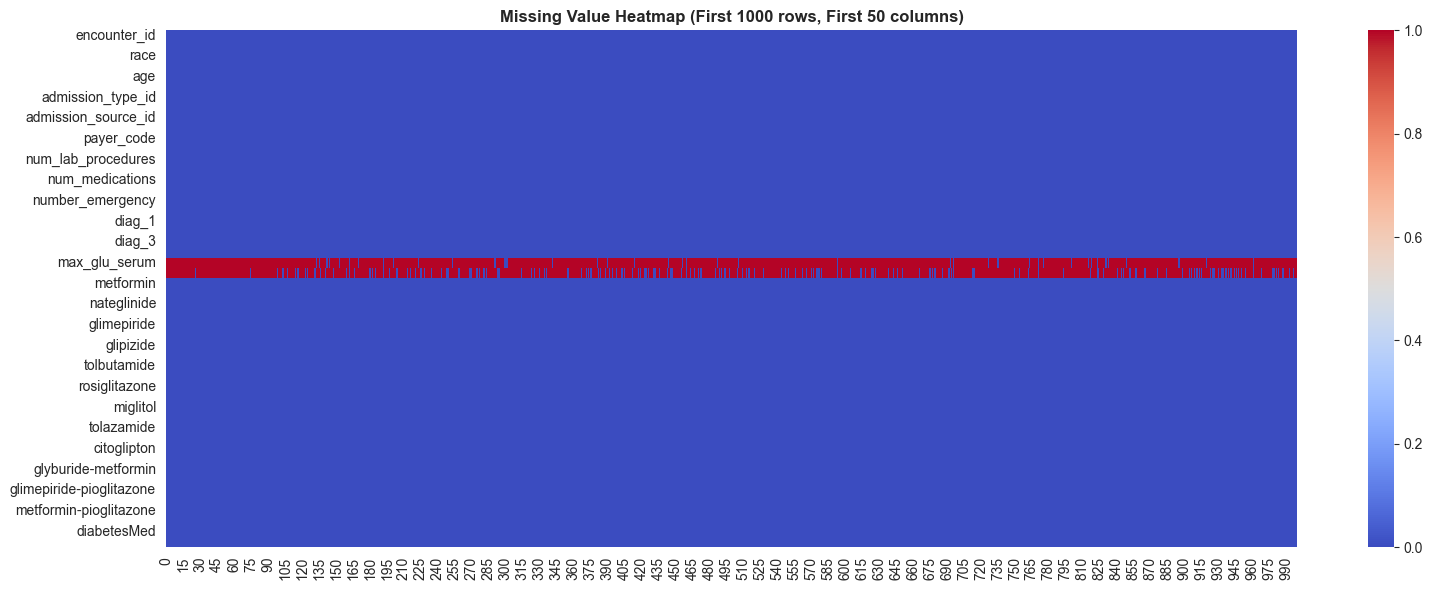

In [30]:
# Create a heatmap of missing values (for first 50 columns)
fig, ax = plt.subplots(figsize=(16, 6))
missing_matrix = df.iloc[:1000, :50].isnull().astype(int)
sns.heatmap(missing_matrix.T, cbar=True, cmap='coolwarm', ax=ax)
ax.set_title('Missing Value Heatmap (First 1000 rows, First 50 columns)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


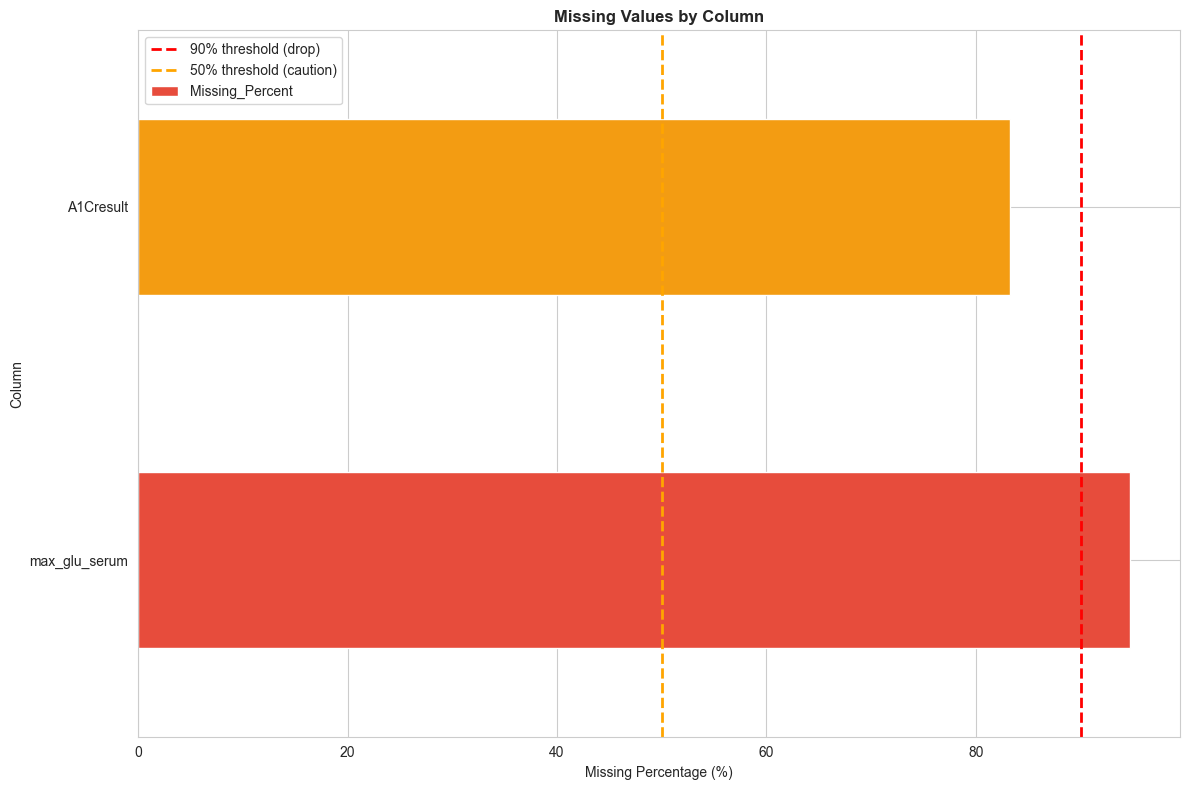


Columns to drop (>90% missing): ['max_glu_serum']


In [31]:
# Visualize missing values
plt.figure(figsize=(12, 8))
missing_data = missing_stats.set_index('Column')['Missing_Percent'].sort_values(ascending=False)

# Highlight columns with >90% missing
colors = ['#e74c3c' if x > 90 else '#f39c12' if x > 50 else '#3498db' for x in missing_data.values]
missing_data.plot(kind='barh', color=colors)
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Column', fontsize=12, fontweight='bold')
plt.axvline(x=90, color='red', linestyle='--', linewidth=2, label='90% threshold (drop)')
plt.axvline(x=50, color='orange', linestyle='--', linewidth=2, label='50% threshold (caution)')
plt.legend()
plt.tight_layout()
plt.show()

# Identify columns to drop
cols_to_drop = missing_stats[missing_stats['Missing_Percent'] > 90]['Column'].tolist()
print(f"\nColumns to drop (>90% missing): {cols_to_drop}")


In [32]:
# Calculate missing value statistics
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print("Missing Value Statistics:")
print(missing_stats)
print(f"\nTotal columns with missing values: {len(missing_stats)}")


Missing Value Statistics:
                      Column  Missing_Count  Missing_Percent
max_glu_serum  max_glu_serum          96420            94.75
A1Cresult          A1Cresult          84748            83.28

Total columns with missing values: 2


## 3. Investigate Missing Values

Missing values can significantly impact model performance. Key columns to examine:
- `weight`: ~97% missing
- `payer_code`: High missing rate
- `medical_specialty`: High missing rate

**Decisions:**
- Drop columns with >90% missing values
- Handle remaining missing values through imputation or removal


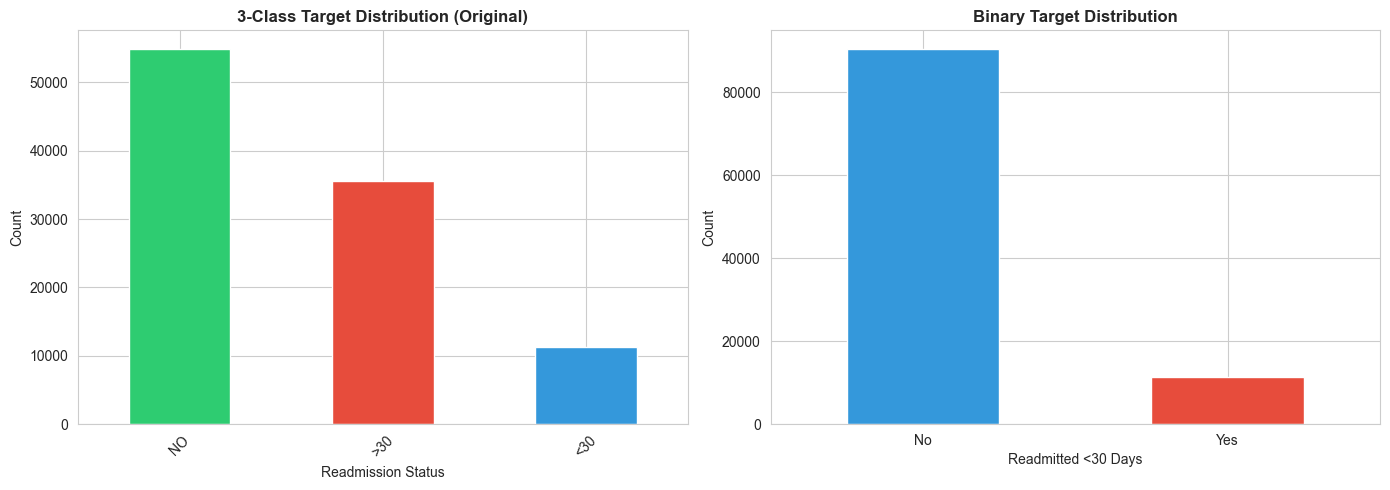

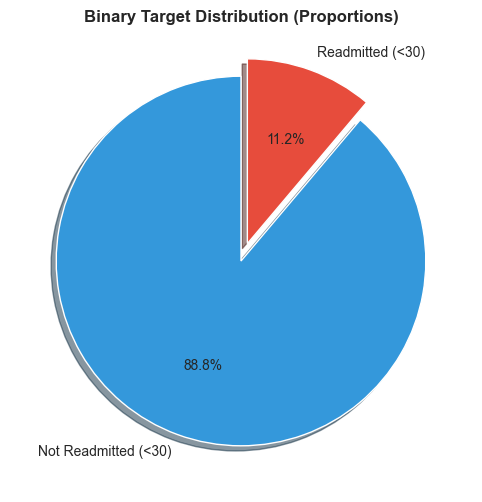

In [33]:
# Visualize 3-class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3-class distribution
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('3-Class Target Distribution (Original)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Readmission Status')
axes[0].tick_params(axis='x', rotation=45)

# Binary distribution
colors = ['#3498db', '#e74c3c']
df['readmitted_binary'].value_counts().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Binary Target Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Readmitted <30 Days')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

# Create pie chart for binary target
labels = ['Not Readmitted (<30)', 'Readmitted (<30)']
sizes = df['readmitted_binary'].value_counts()
explode = (0, 0.1)
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90, colors=colors)
plt.title('Binary Target Distribution (Proportions)', fontsize=12, fontweight='bold')
plt.show()


In [34]:
# Analyze original 3-class target
print("Original Target Distribution (3-class):")
print(df['readmitted'].value_counts())
print("\nProportions:")
print(df['readmitted'].value_counts(normalize=True) * 100)

# Create binary target
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print("\n" + "="*80)
print("Binary Target Distribution:")
print(df['readmitted_binary'].value_counts())
print("\nProportions:")
readmit_counts = df['readmitted_binary'].value_counts(normalize=True) * 100
print(f"Readmitted <30 days: {readmit_counts[1]:.2f}%")
print(f"Not readmitted or >30 days: {readmit_counts[0]:.2f}%")


Original Target Distribution (3-class):
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Proportions:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

Binary Target Distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Proportions:
Readmitted <30 days: 11.16%
Not readmitted or >30 days: 88.84%


## 2. Analyze Target Variable Distribution

The target variable `readmitted` has 3 classes:
- `<30`: Readmitted within 30 days
- `>30`: Readmitted after 30 days
- `NO`: Not readmitted

We will convert this to binary classification: **readmitted within 30 days = 1, else = 0**


In [35]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())
print("\nData Types:")
print(df.dtypes)
print("\nMemory Usage:")
print(df.memory_usage(deep=True))


Dataset Statistics:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000

In [36]:
# Define data paths
data_dir = '../diabetes+130-us+hospitals+for+years+1999-2008/'
data_path = data_dir + 'diabetic_data.csv'
mapping_path = data_dir + 'IDS_mapping.csv'

# Load the datasets
df = pd.read_csv(data_path)
df_mapping = pd.read_csv(mapping_path)

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First few rows of the dataset:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())


Dataset Shape: (101766, 50)

First few rows of the dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital payer_code         medical_specialty  num_lab_procedur

## 1. Load and Explore the Dataset


In [37]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)


# Phase 1: Exploratory Data Analysis (EDA)
## Diabetes 130-US Hospitals Readmission Dataset

This notebook explores the structure, patterns, and key characteristics of the readmission dataset.

**Key Objectives:**
- Analyze target distribution and class imbalance
- Identify missing values and decide on handling strategy
- Explore correlations with key features
- Investigate demographic disparities in readmission rates
